<a href="https://colab.research.google.com/github/asrianda/jurnal/blob/main/C4_5_QUADRATIC_GAIN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
df=pd.read_csv('synthetic_fooddelivery_dataset.csv')
df.shape

(8500, 11)

In [ ]:
df.isnull().sum()

,0
ID_Pesanan,0
Waktu_Transaksi,0
Kategori_Menu,0
Harga_Pesanan,0
Jarak_Kirim_KM,595
Waktu_Tunggu_Menit,0
Rating_Pelanggan,1700
Ulasan_Teks,1700
Status_Promo,0
Tingkat_Keluhan,0


In [ ]:
import pandas as pd
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.model_selection import train_test_split
import pprint

# ==============================
# Load Dataset
# ==============================
data = pd.read_csv('synthetic_fooddelivery_dataset.csv')

# FIX: ubah semua ke string agar aman
data = data.astype(str)

target_col = data.columns[-1]

# ==============================
# Train-Test Split
# ==============================
train_data, test_data = train_test_split(data, test_size=0.3, random_state=42)

# ==============================
# Entropy Function
# ==============================
def entropy(y):
    values, counts = np.unique(y, return_counts=True)
    probs = counts / counts.sum()
    return -np.sum(probs * np.log2(probs + 1e-9))

# ==============================
# Information Gain
# ==============================
def information_gain(data, feature, target):
    total_entropy = entropy(data[target])
    values, counts = np.unique(data[feature], return_counts=True)

    weighted_entropy = 0
    for v, count in zip(values, counts):
        subset = data[data[feature] == v]
        weighted_entropy += (count / len(data)) * entropy(subset[target])

    return total_entropy - weighted_entropy

# ==============================
# Split Information
# ==============================
def split_info(data, feature):
    values, counts = np.unique(data[feature], return_counts=True)
    probs = counts / counts.sum()
    return -np.sum(probs * np.log2(probs + 1e-9))

# ==============================
# Quadratic Gain Score
# ==============================
def quadratic_gain_score(data, feature, target):
    gain = information_gain(data, feature, target)
    split = split_info(data, feature)

    if split == 0:
        return 0
    return (gain ** 2) / split

# ==============================
# Build Tree
# ==============================
def build_tree(data, features, target):

    # Jika semua label sama
    if len(np.unique(data[target])) == 1:
        return data[target].iloc[0]

    # Jika fitur habis
    if len(features) == 0:
        return data[target].mode()[0]

    # Hitung score
    scores = {}
    for f in features:
        scores[f] = quadratic_gain_score(data, f, target)

    # Pilih fitur terbaik
    best_feature = max(scores, key=scores.get)

    tree = {best_feature: {}}

    for value in np.unique(data[best_feature]):
        subset = data[data[best_feature] == value]

        if subset.empty:
            tree[best_feature][value] = data[target].mode()[0]
        else:
            remaining_features = [f for f in features if f != best_feature]
            subtree = build_tree(subset, remaining_features, target)
            tree[best_feature][value] = subtree

    return tree

# ==============================
# Prediction Function
# ==============================
def predict_instance(tree, instance):
    if not isinstance(tree, dict):
        return tree

    root = list(tree.keys())[0]
    value = instance[root]

    if value in tree[root]:
        return predict_instance(tree[root][value], instance)
    else:
        return None  # unseen value

def predict(tree, data):
    return data.apply(lambda x: predict_instance(tree, x), axis=1)

# ==============================
# Training
# ==============================
features = list(train_data.columns[:-1])
tree_model = build_tree(train_data, features, target_col)

print("Decision Tree:")
pprint.pprint(tree_model)

# ==============================
# Testing
# ==============================
y_true = test_data[target_col]
y_pred = predict(tree_model, test_data)

# Handle None prediction
y_pred = y_pred.fillna(y_true.mode()[0])

# ==============================
# Evaluation
# ==============================
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average='weighted')
recall = recall_score(y_true, y_pred, average='weighted')
f1 = f1_score(y_true, y_pred, average='weighted')

print("\nEvaluation Results:")
print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1-score :", f1)

Streaming output truncated to the last 5000 lines.
                'ORD-2024-001391': 'Selesai',
                'ORD-2024-001392': 'Selesai',
                'ORD-2024-001393': 'Selesai',
                'ORD-2024-001395': 'Selesai',
                'ORD-2024-001396': 'Selesai',
                'ORD-2024-001397': 'Selesai',
                'ORD-2024-001399': 'Selesai',
                'ORD-2024-001400': 'Selesai',
                'ORD-2024-001402': 'Selesai',
                'ORD-2024-001404': 'Selesai',
                'ORD-2024-001405': 'Selesai',
                'ORD-2024-001409': 'Selesai',
                'ORD-2024-001410': 'Selesai',
                'ORD-2024-001412': 'Selesai',
                'ORD-2024-001414': 'Dibatalkan',
                'ORD-2024-001416': 'Selesai',
                'ORD-2024-001417': 'Selesai',
                'ORD-2024-001419': 'Selesai',
                'ORD-2024-001423': 'Selesai',
                'ORD-2024-001425': 'Selesai',
                'ORD-2024-

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
# ==============================
# Rename Columns (Indonesia → English)
# ==============================
data = data.rename(columns={
    'ID_Pesanan': 'Order_ID',
    'Waktu_Transaksi': 'Transaction_Time',
    'Kategori_Menu': 'Menu_Category',
    'Harga_Pesanan': 'Order_Price',
    'Jarak_Kirim_KM': 'Delivery_Distance_KM',
    'Waktu_Tunggu_Menit': 'Waiting_Time_Minutes',
    'Rating_Pelanggan': 'Customer_Rating',
    'Ulasan_Teks': 'Review_Text',
    'Status_Promo': 'Promo_Status',
    'Tingkat_Keluhan': 'Complaint_Level',
    'Status_Pesanan': 'Order_Status'
})

# ==============================
# Translate Values
# ==============================
value_mapping = {
    'Tidak Ada': 'None',
    'Rendah': 'Low',
    'Sedang': 'Medium',
    'Tinggi': 'High',
    'Selesai': 'Completed',
    'Dibatalkan': 'Cancelled',
    'Ya': 'Yes',
    'Tidak': 'No'
}

data = data.replace(value_mapping)

# ==============================
# Drop ID (tidak perlu untuk model)
# ==============================
data = data.drop(columns=['Order_ID'])

In [ ]:
data.head()

,Transaction_Time,Menu_Category,Order_Price,Delivery_Distance_KM,Waiting_Time_Minutes,Customer_Rating,Review_Text,Promo_Status,Complaint_Level,Order_Status
0,2024-03-22 13:15:14,Kopi,9000,nan,27,4.0,Sesuai pesanan,False,None,Completed
1,2024-01-14 17:05:37,Mie,21000,3.742238440029988,37,nan,nan,False,None,Completed
2,2024-01-04 12:32:38,Martabak,33500,12.677149433985925,49,nan,nan,True,Low,Completed
3,2024-01-26 22:34:26,Kopi,13500,2.338085240758421,20,5.0,Mantap gan!,False,None,Completed
4,2024-03-16 11:48:51,Ayam,47500,0.9497636057479284,27,4.0,Top bgt kualitasnya,True,Low,Completed


**Program Lengkap dan Menggunakan Bahasa Inggris**

In [ ]:
import pandas as pd
import numpy as np

# ==============================
# LOAD DATASET
# ==============================
data = pd.read_csv('synthetic_fooddelivery_dataset.csv')

# ==============================
# RENAME KOLOM (INDO → ENG)
# ==============================
data = data.rename(columns={
    'ID_Pesanan': 'Order_ID',
    'Waktu_Transaksi': 'Transaction_Time',
    'Kategori_Menu': 'Menu_Category',
    'Harga_Pesanan': 'Order_Price',
    'Jarak_Kirim_KM': 'Delivery_Distance_KM',
    'Waktu_Tunggu_Menit': 'Waiting_Time_Minutes',
    'Rating_Pelanggan': 'Customer_Rating',
    'Ulasan_Teks': 'Review_Text',
    'Status_Promo': 'Promo_Status',
    'Tingkat_Keluhan': 'Complaint_Level',
    'Status_Pesanan': 'Order_Status'
})

# ==============================
# TRANSLATE VALUE
# ==============================
value_mapping = {
    'Ya': 'Yes', 'Tidak': 'No',
    'Tidak Ada': 'None', 'Rendah': 'Low', 'Sedang': 'Medium', 'Tinggi': 'High',
    'Selesai': 'Completed', 'Dibatalkan': 'Cancelled',
    'Diproses': 'Processing', 'Menunggu': 'Pending',
    'Makanan': 'Food', 'Minuman': 'Beverage',
    'Cepat Saji': 'FastFood', 'Pencuci Mulut': 'Dessert'
}

data = data.replace(value_mapping)

# ==============================
# DROP ID (tidak dipakai)
# ==============================
data = data.drop(columns=['Order_ID'])

# ==============================
# HANDLE TIPE DATA (FIX ERROR)
# ==============================
# ubah semua jadi string agar tidak error campuran tipe
for col in data.columns:
    data[col] = data[col].astype(str)

# ==============================
# FUNGSI ENTROPY
# ==============================
def entropy(S):
    values, counts = np.unique(S, return_counts=True)
    probs = counts / counts.sum()
    return -np.sum(probs * np.log2(probs + 1e-9))

# ==============================
# INFORMATION GAIN
# ==============================
def information_gain(data, feature, target):
    total_entropy = entropy(data[target])
    values, counts = np.unique(data[feature], return_counts=True)

    weighted_entropy = 0
    for v in values:
        subset = data[data[feature] == v]
        weighted_entropy += (len(subset) / len(data)) * entropy(subset[target])

    return total_entropy - weighted_entropy

# ==============================
# SPLIT INFO
# ==============================
def split_info(data, feature):
    values, counts = np.unique(data[feature], return_counts=True)
    probs = counts / counts.sum()
    return -np.sum(probs * np.log2(probs + 1e-9))

# ==============================
# QUADRATIC GAIN SCORE
# Score = Gain^2 / SplitInfo
# ==============================
def quadratic_gain_score(data, feature, target):
    gain = information_gain(data, feature, target)
    split = split_info(data, feature)

    if split == 0:
        return 0
    return (gain ** 2) / split

# ==============================
# BUILD TREE
# ==============================
def build_tree(data, features, target):

    # jika semua target sama
    if len(np.unique(data[target])) == 1:
        return data[target].iloc[0]

    # jika fitur habis
    if len(features) == 0:
        return data[target].mode()[0]

    # hitung score tiap fitur
    scores = {}
    for feature in features:
        scores[feature] = quadratic_gain_score(data, feature, target)

    # pilih fitur terbaik
    best_feature = max(scores, key=scores.get)

    tree = {best_feature: {}}

    # buat subtree
    for value in np.unique(data[best_feature]):
        subset = data[data[best_feature] == value]

        if subset.empty:
            tree[best_feature][value] = data[target].mode()[0]
        else:
            remaining_features = [f for f in features if f != best_feature]
            subtree = build_tree(subset, remaining_features, target)
            tree[best_feature][value] = subtree

    return tree

# ==============================
# TRAIN MODEL
# ==============================
target_col = 'Order_Status'
features = list(data.columns)
features.remove(target_col)

tree_model = build_tree(data, features, target_col)

# ==============================
# OUTPUT TREE
# ==============================
import pprint
print("\n=== Decision Tree (C4.5 Quadratic Gain) ===\n")
#pprint.pprint(tree_model)


=== Decision Tree (C4.5 Quadratic Gain) ===



In [ ]:
# Save new dataset
output_path = 'food_delivery_dataset.csv'
data.to_csv(output_path, index=False)

In [ ]:
#data.isnull().sum()
data.head()

,Transaction_Time,Menu_Category,Order_Price,Delivery_Distance_KM,Waiting_Time_Minutes,Customer_Rating,Review_Text,Promo_Status,Complaint_Level,Order_Status
0,2024-03-22 13:15:14,Kopi,9000,0.5,27,4.0,Sesuai pesanan,False,Low,Completed
1,2024-01-14 17:05:37,Mie,21000,3.742238440029988,37,5.0,Makanan hangat sampai,False,Low,Completed
2,2024-01-04 12:32:38,Martabak,33500,12.677149433985925,49,5.0,Makanan hangat sampai,True,Low,Completed
3,2024-01-26 22:34:26,Kopi,13500,2.338085240758421,20,5.0,Mantap gan!,False,Low,Completed
4,2024-03-16 11:48:51,Ayam,47500,0.9497636057479284,27,4.0,Top bgt kualitasnya,True,Low,Completed


In [ ]:
#print(type(data['Delivery_Distance_KM'][0]))
import numpy as np

data = data.replace("NaN", np.nan)

In [ ]:
# convert string nan → NaN
data = data.replace("NaN", np.nan)

# cek missing
print(data.isnull().sum())

# isi missing (opsional)
for col in data.columns:
    data[col].fillna(data[col].mode()[0], inplace=True)

Transaction_Time        0
Menu_Category           0
Order_Price             0
Delivery_Distance_KM    0
Waiting_Time_Minutes    0
Customer_Rating         0
Review_Text             0
Promo_Status            0
Complaint_Level         0
Order_Status            0
dtype: int64


/tmp/ipykernel_211/3130380180.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data[col].fillna(data[col].mode()[0], inplace=True)


In [ ]:
data = data.replace("NaN", np.nan)

In [ ]:
import pandas as pd
import numpy as np
df=pd.read_csv('food_delivery_dataset.csv')
df.head()

,Transaction_Time,Menu_Category,Order_Price,Delivery_Distance_KM,Waiting_Time_Minutes,Customer_Rating,Review_Text,Promo_Status,Complaint_Level,Order_Status
0,2024-03-22 13:15:14,Kopi,9000,0.500000,27,4.0,Sesuai pesanan,False,Low,Completed
1,2024-01-14 17:05:37,Mie,21000,3.742238,37,5.0,Makanan hangat sampai,False,Low,Completed
2,2024-01-04 12:32:38,Martabak,33500,12.677149,49,5.0,Makanan hangat sampai,True,Low,Completed
3,2024-01-26 22:34:26,Kopi,13500,2.338085,20,5.0,Mantap gan!,False,Low,Completed
4,2024-03-16 11:48:51,Ayam,47500,0.949764,27,4.0,Top bgt kualitasnya,True,Low,Completed


In [ ]:
import numpy as np

# Ubah semua bentuk missing jadi NaN asli
df = df.replace(["nan", "NaN","None", "", " "], np.nan)

# Isi semua missing
for col in df.columns:
    df[col].fillna(df[col].mode()[0], inplace=True)

# cek ulang
print(df.isnull().sum())

Transaction_Time        0
Menu_Category           0
Order_Price             0
Delivery_Distance_KM    0
Waiting_Time_Minutes    0
Customer_Rating         0
Review_Text             0
Promo_Status            0
Complaint_Level         0
Order_Status            0
dtype: int64


/tmp/ipykernel_603/3300257176.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0], inplace=True)
/tmp/ipykernel_603/3300257176.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try usi

In [ ]:
print(df['Complaint_Level'].unique())

['Low' 'High']


**Program Sebenarnya**

In [ ]:
df=pd.read_csv('food_delivery_dataset.csv')
df.head()

,Transaction_Time,Menu_Category,Order_Price,Delivery_Distance_KM,Waiting_Time_Minutes,Customer_Rating,Review_Text,Promo_Status,Complaint_Level,Order_Status
0,2024-03-22 13:15:14,Kopi,9000,0.500000,27,4.0,Sesuai pesanan,False,Low,Completed
1,2024-01-14 17:05:37,Mie,21000,3.742238,37,5.0,Makanan hangat sampai,False,Low,Completed
2,2024-01-04 12:32:38,Martabak,33500,12.677149,49,5.0,Makanan hangat sampai,True,Low,Completed
3,2024-01-26 22:34:26,Kopi,13500,2.338085,20,5.0,Mantap gan!,False,Low,Completed
4,2024-03-16 11:48:51,Ayam,47500,0.949764,27,4.0,Top bgt kualitasnya,True,Low,Completed


In [ ]:
# ==============================
# CLEAN DATA
# ==============================

df['Menu_Category'] = df['Menu_Category'].astype(str).str.lower().str.strip()

# ==============================
# MAPPING ITEM → ENGLISH
# ==============================

menu_mapping = {
    'ayam': 'chicken',
    'kopi': 'coffee',
    'mie': 'noodle',
    'martabak': 'martabak'
}

df['Menu_Category'] = df['Menu_Category'].replace(menu_mapping)

# ==============================
# CEK HASIL
# ==============================

print("=== HASIL TRANSLATE ===")
print(df['Menu_Category'].unique())

# pilih kolom yang digunakan
selected_columns = [
    'Menu_Category',
    'Order_Price',
    'Delivery_Distance_KM',
    'Waiting_Time_Minutes',
    'Customer_Rating',
    'Promo_Status',
    'Complaint_Level',
    'Order_Status'
]

# tampilkan data
#print(df[selected_columns].head())
df=df[selected_columns]
df.head()

=== HASIL TRANSLATE ===
['coffee' 'noodle' 'martabak' 'chicken']


,Menu_Category,Order_Price,Delivery_Distance_KM,Waiting_Time_Minutes,Customer_Rating,Promo_Status,Complaint_Level,Order_Status
0,coffee,9000,0.500000,27,4.0,False,Low,Completed
1,noodle,21000,3.742238,37,5.0,False,Low,Completed
2,martabak,33500,12.677149,49,5.0,True,Low,Completed
3,coffee,13500,2.338085,20,5.0,False,Low,Completed
4,chicken,47500,0.949764,27,4.0,True,Low,Completed


In [ ]:
# Save new dataset
output_path = 'food_delivery_.csv'
df.to_csv(output_path, index=False)

In [ ]:
df['Complaint_Level'].value_counts()

,count
Complaint_Level,
Low,7474
High,1026


In [ ]:
df.shape


(8500, 8)

In [ ]:
df.head()

,Menu_Category,Order_Price,Delivery_Distance_KM,Waiting_Time_Minutes,Customer_Rating,Promo_Status,Complaint_Level,Order_Status
0,coffee,9000,0.500000,27,4.0,False,Low,Completed
1,noodle,21000,3.742238,37,5.0,False,Low,Completed
2,martabak,33500,12.677149,49,5.0,True,Low,Completed
3,coffee,13500,2.338085,20,5.0,False,Low,Completed
4,chicken,47500,0.949764,27,4.0,True,Low,Completed


## **Kerja disini**

In [ ]:
import pandas as pd
import numpy as np
dt=pd.read_csv('food_delivery_.csv')
dt.head()

,Menu_Category,Order_Price,Delivery_Distance_KM,Waiting_Time_Minutes,Customer_Rating,Promo_Status,Complaint_Level,Order_Status
0,coffee,9000,0.500000,27,4.0,False,Low,Completed
1,noodle,21000,3.742238,37,5.0,False,Low,Completed
2,martabak,33500,12.677149,49,5.0,True,Low,Completed
3,coffee,13500,2.338085,20,5.0,False,Low,Completed
4,chicken,47500,0.949764,27,4.0,True,Low,Completed


In [ ]:
dt['Customer_Rating'].value_counts()

,count
Customer_Rating,
5.0,4909
4.0,2325
3.0,742
2.0,297
1.0,227


**Perbandingan C4.5 dan C4.5 Modifikasi**

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

# ==============================
# LOAD DATASET
# ==============================
df = pd.read_csv("food_delivery_.csv")

# ==============================
# PILIH FITUR
# ==============================
selected_columns = [
    'Menu_Category',
    'Order_Price',
    'Delivery_Distance_KM',
    'Waiting_Time_Minutes',
    'Customer_Rating',
    'Promo_Status',
    'Complaint_Level'
]

df = df[selected_columns]

# ==============================
# CLEAN DATA
# ==============================
df = df.replace(['', 'None', 'nan', 'NaN'], np.nan)
df = df.dropna()

# ==============================
# DISCRETIZATION
# ==============================
df['Order_Price'] = pd.qcut(df['Order_Price'], 3, labels=['Low','Medium','High'])
df['Delivery_Distance_KM'] = pd.qcut(df['Delivery_Distance_KM'], 3, labels=['Near','Medium','Far'])
df['Waiting_Time_Minutes'] = pd.qcut(df['Waiting_Time_Minutes'], 3, labels=['Fast','Normal','Slow'])

df['Customer_Rating'] = pd.cut(
    df['Customer_Rating'],
    bins=[0,3,4,5],
    labels=['Low','Medium','High']
)

# ==============================
# SPLIT DATA
# ==============================
target = 'Complaint_Level'
X = df.drop(columns=[target])
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

train_data = pd.concat([X_train, y_train], axis=1)

# ==============================
# ENTROPY (Eq.1)
# ==============================
def entropy(S):
    values, counts = np.unique(S, return_counts=True)
    total = len(S)
    ent = 0
    for count in counts:
        p = count / total
        ent += -p * np.log2(p + 1e-9)
    return ent

# ==============================
# INFORMATION GAIN (Eq.2)
# ==============================
def information_gain(data, feature):
    total_entropy = entropy(data[target])
    total = len(data)

    weighted_entropy = 0
    for v in data[feature].unique():
        S_v = data[data[feature] == v]
        weight = len(S_v) / total
        weighted_entropy += weight * entropy(S_v[target])

    return total_entropy - weighted_entropy

# ==============================
# SPLIT INFO (Eq.3)
# ==============================
def split_info(data, feature):
    total = len(data)
    split = 0

    for v in data[feature].unique():
        S_v = data[data[feature] == v]
        p = len(S_v) / total
        split += -p * np.log2(p + 1e-9)

    return split

# ==============================
# GAIN RATIO MODIFIED (Eq.5)
# ==============================
def gain_ratio_quadratic(data, feature):
    gain = information_gain(data, feature)
    split = split_info(data, feature)

    if split == 0:
        return 0

    return (gain ** 2) / split

# ==============================
# PILIH FITUR TERBAIK
# ==============================
def select_best_feature(data, features):
    scores = [gain_ratio_quadratic(data, f) for f in features]
    return features[np.argmax(scores)]

# ==============================
# BUILD TREE (DEPTH = 6)
# ==============================
def build_tree(data, features, depth=0, max_depth=6):

    # jika satu kelas
    if len(np.unique(data[target])) == 1:
        return data[target].iloc[0]

    # stopping condition
    if len(features) == 0 or depth == max_depth:
        return data[target].mode()[0]

    best_feature = select_best_feature(data, features)

    tree = {best_feature: {}}

    for value in data[best_feature].unique():
        subset = data[data[best_feature] == value]

        if len(subset) == 0:
            tree[best_feature][value] = data[target].mode()[0]
        else:
            remaining = [f for f in features if f != best_feature]
            tree[best_feature][value] = build_tree(
                subset, remaining, depth+1, max_depth
            )

    return tree

# ==============================
# PREDICT
# ==============================
def predict(tree, sample):
    if not isinstance(tree, dict):
        return tree

    root = list(tree.keys())[0]

    if sample[root] in tree[root]:
        return predict(tree[root][sample[root]], sample)
    else:
        return y_train.mode()[0]

# ==============================
# TRAIN MODEL
# ==============================
features = list(X_train.columns)
tree_model = build_tree(train_data, features, max_depth=6)

# ==============================
# PREDICTION
# ==============================
y_pred = [predict(tree_model, row) for row in X_test.to_dict('records')]

# ==============================
# EVALUATION
# ==============================
print("=== CLASSIFICATION REPORT (MODIFIED C4.5) ===")
print(classification_report(y_test, y_pred))

=== CLASSIFICATION REPORT (MODIFIED C4.5) ===
              precision    recall  f1-score   support

        High       0.37      0.16      0.22       205
         Low       0.89      0.96      0.93      1495

    accuracy                           0.87      1700
   macro avg       0.63      0.56      0.57      1700
weighted avg       0.83      0.87      0.84      1700



**C4.5 Standard**

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

# ==============================
# LOAD DATA
# ==============================
df = pd.read_csv("food_delivery_.csv")

selected_columns = [
    'Menu_Category',
    'Order_Price',
    'Delivery_Distance_KM',
    'Waiting_Time_Minutes',
    'Customer_Rating',
    'Promo_Status',
    'Complaint_Level'
]

df = df[selected_columns]

# ==============================
# CLEAN DATA
# ==============================
df = df.replace(['', 'None', 'nan', 'NaN'], np.nan)
df = df.dropna()

# ==============================
# DISCRETIZATION
# ==============================
df['Order_Price'] = pd.qcut(df['Order_Price'], 3, labels=['Low','Medium','High'])
df['Delivery_Distance_KM'] = pd.qcut(df['Delivery_Distance_KM'], 3, labels=['Near','Medium','Far'])
df['Waiting_Time_Minutes'] = pd.qcut(df['Waiting_Time_Minutes'], 3, labels=['Fast','Normal','Slow'])

df['Customer_Rating'] = pd.cut(
    df['Customer_Rating'],
    bins=[0,3,4,5],
    labels=['Low','Medium','High']
)

# ==============================
# SPLIT DATA
# ==============================
target = 'Complaint_Level'

X = df.drop(columns=[target])
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

train_data = pd.concat([X_train, y_train], axis=1)

# ==============================
# ENTROPY
# ==============================
def entropy(S):
    values, counts = np.unique(S, return_counts=True)
    total = len(S)
    return -np.sum((counts/total) * np.log2(counts/total + 1e-9))

# ==============================
# INFORMATION GAIN
# ==============================
def information_gain(data, feature, target):
    total_entropy = entropy(data[target])
    total = len(data)

    weighted_entropy = 0
    for v in data[feature].unique():
        subset = data[data[feature] == v]
        weighted_entropy += (len(subset)/total) * entropy(subset[target])

    return total_entropy - weighted_entropy

# ==============================
# SPLIT INFO
# ==============================
def split_info(data, feature):
    total = len(data)
    split = 0

    for v in data[feature].unique():
        subset = data[data[feature] == v]
        p = len(subset) / total
        split += -p * np.log2(p + 1e-9)

    return split

# ==============================
# GAIN RATIO (C4.5)
# ==============================
def gain_ratio(data, feature, target):
    gain = information_gain(data, feature, target)
    split = split_info(data, feature)

    if split == 0:
        return 0

    return gain / split

# ==============================
# SELECT BEST FEATURE
# ==============================
def select_best_feature(data, features, target):
    scores = [gain_ratio(data, f, target) for f in features]
    return features[np.argmax(scores)]

# ==============================
# BUILD TREE (DEPTH = 6)
# ==============================
def build_tree_c45(data, features, target, depth=0, max_depth=6):

    if len(np.unique(data[target])) == 1:
        return data[target].iloc[0]

    if len(features) == 0 or depth == max_depth:
        return data[target].mode()[0]

    best_feature = select_best_feature(data, features, target)

    tree = {best_feature: {}}

    for value in data[best_feature].unique():
        subset = data[data[best_feature] == value]

        if len(subset) == 0:
            tree[best_feature][value] = data[target].mode()[0]
        else:
            remaining = [f for f in features if f != best_feature]
            tree[best_feature][value] = build_tree_c45(
                subset, remaining, target, depth+1, max_depth
            )

    return tree

# ==============================
# PREDICT
# ==============================
def predict(tree, sample):
    if not isinstance(tree, dict):
        return tree

    root = list(tree.keys())[0]

    if sample[root] in tree[root]:
        return predict(tree[root][sample[root]], sample)
    else:
        return y_train.mode()[0]

# ==============================
# TRAIN MODEL
# ==============================
features = list(X_train.columns)
tree_model = build_tree_c45(train_data, features, target, max_depth=6)

# ==============================
# PREDICTION
# ==============================
y_pred = [predict(tree_model, row) for row in X_test.to_dict('records')]

# ==============================
# EVALUATION
# ==============================
print("=== CLASSIFICATION REPORT C4.5 ===")
print(classification_report(y_test, y_pred))

=== CLASSIFICATION REPORT C4.5 ===
              precision    recall  f1-score   support

        High       0.37      0.16      0.22       205
         Low       0.89      0.96      0.93      1495

    accuracy                           0.87      1700
   macro avg       0.63      0.56      0.57      1700
weighted avg       0.83      0.87      0.84      1700



In [ ]:
df['Customer_Rating'].value_counts()

,count
Customer_Rating,
High,4909
Medium,2325
Low,1266


**Perbandingan C4.5 dan C4.5 Modifikasi**

**Program C4.5 Klasik**

In [ ]:
# ==============================
# IMPORT LIBRARY
# ==============================
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# ==============================
# LOAD DATA
# ==============================
df = pd.read_csv("food_delivery_.csv")

# ==============================
# PILIH FITUR
# ==============================
selected_columns = [
    'Menu_Category',
    'Order_Price',
    'Delivery_Distance_KM',
    'Waiting_Time_Minutes',
    'Customer_Rating',
    'Promo_Status',
    'Complaint_Level'
]

df = df[selected_columns]

# ==============================
# CLEAN DATA
# ==============================
df = df.replace(['', 'None', 'nan', 'NaN'], np.nan)
df = df.dropna()

# ==============================
# DISCRETIZATION (HANYA NUMERIK LAIN)
# ==============================
df['Order_Price'] = pd.qcut(df['Order_Price'], 3, labels=['Low','Medium','High'])
df['Delivery_Distance_KM'] = pd.qcut(df['Delivery_Distance_KM'], 3, labels=['Near','Medium','Far'])
df['Waiting_Time_Minutes'] = pd.qcut(df['Waiting_Time_Minutes'], 3, labels=['Fast','Normal','Slow'])

# 👉 Customer_Rating TIDAK DIUBAH (sesuai permintaan)

# ==============================
# SPLIT DATA
# ==============================
target = 'Complaint_Level'

X = df.drop(columns=[target])
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

train_data = pd.concat([X_train, y_train], axis=1)

# ==============================
# ENTROPY
# ==============================
def entropy(S):
    values, counts = np.unique(S, return_counts=True)
    probs = counts / counts.sum()
    return -np.sum(probs * np.log2(probs + 1e-9))

# ==============================
# INFORMATION GAIN
# ==============================
def information_gain(data, feature, target):
    total_entropy = entropy(data[target])
    total = len(data)

    weighted_entropy = 0
    for v in data[feature].unique():
        subset = data[data[feature] == v]
        weighted_entropy += (len(subset)/total) * entropy(subset[target])

    return total_entropy - weighted_entropy

# ==============================
# SPLIT INFO
# ==============================
def split_info(data, feature):
    total = len(data)
    split = 0

    for v in data[feature].unique():
        subset = data[data[feature] == v]
        p = len(subset) / total
        split += -p * np.log2(p + 1e-9)

    return split

# ==============================
# GAIN RATIO
# ==============================
def gain_ratio(data, feature, target):
    gain = information_gain(data, feature, target)
    split = split_info(data, feature)
    return gain / split if split != 0 else 0

# ==============================
# SELECT BEST FEATURE
# ==============================
def select_best_feature(data, features, target):
    scores = [gain_ratio(data, f, target) for f in features]
    return features[np.argmax(scores)]

# ==============================
# BUILD TREE
# ==============================
def build_tree(data, features, target, depth=0, max_depth=6):

    if len(np.unique(data[target])) == 1:
        return data[target].iloc[0]

    if len(features) == 0 or depth == max_depth:
        return data[target].mode()[0]

    best_feature = select_best_feature(data, features, target)
    tree = {best_feature: {}}

    for value in data[best_feature].unique():
        subset = data[data[best_feature] == value]

        if len(subset) == 0:
            tree[best_feature][value] = data[target].mode()[0]
        else:
            remaining = [f for f in features if f != best_feature]
            tree[best_feature][value] = build_tree(
                subset, remaining, target, depth+1, max_depth
            )

    return tree

# ==============================
# PREDICT
# ==============================
def predict(tree, sample):
    if not isinstance(tree, dict):
        return tree

    root = list(tree.keys())[0]

    if sample[root] in tree[root]:
        return predict(tree[root][sample[root]], sample)
    else:
        return y_train.mode()[0]

# ==============================
# ITERASI DEPTH 1–20
# ==============================
results = []
features = list(X_train.columns)

for d in range(1, 21):

    tree_model = build_tree(train_data, features, target, max_depth=d)

    y_pred = [predict(tree_model, row) for row in X_test.to_dict('records')]

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, pos_label='High', zero_division=0)
    rec = recall_score(y_test, y_pred, pos_label='High', zero_division=0)
    f1 = f1_score(y_test, y_pred, pos_label='High', zero_division=0)

    results.append([d, acc, prec, rec, f1])

# ==============================
# HASIL
# ==============================
results_df = pd.DataFrame(results, columns=[
    'Depth','Accuracy','Precision','Recall','F1-score'
])

print("=== HASIL C4.5 TANPA DISCRETIZATION RATING ===")
print(results_df)

=== HASIL C4.5 TANPA DISCRETIZATION RATING ===
    Depth  Accuracy  Precision    Recall  F1-score
0       1  0.915294   0.796117  0.400000  0.532468
1       2  0.915294   0.796117  0.400000  0.532468
2       3  0.914118   0.786408  0.395122  0.525974
3       4  0.911765   0.766990  0.385366  0.512987
4       5  0.906471   0.716981  0.370732  0.488746
5       6  0.900588   0.680000  0.331707  0.445902
6       7  0.900588   0.680000  0.331707  0.445902
7       8  0.900588   0.680000  0.331707  0.445902
8       9  0.900588   0.680000  0.331707  0.445902
9      10  0.900588   0.680000  0.331707  0.445902
10     11  0.900588   0.680000  0.331707  0.445902
11     12  0.900588   0.680000  0.331707  0.445902
12     13  0.900588   0.680000  0.331707  0.445902
13     14  0.900588   0.680000  0.331707  0.445902
14     15  0.900588   0.680000  0.331707  0.445902
15     16  0.900588   0.680000  0.331707  0.445902
16     17  0.900588   0.680000  0.331707  0.445902
17     18  0.900588   0.680000  0.3

**C4.5 Modifikasi**

In [ ]:
# ==============================
# IMPORT LIBRARY
# ==============================
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# ==============================
# LOAD DATA
# ==============================
df = pd.read_csv("food_delivery_.csv")

# ==============================
# PILIH FITUR
# ==============================
selected_columns = [
    'Menu_Category',
    'Order_Price',
    'Delivery_Distance_KM',
    'Waiting_Time_Minutes',
    'Customer_Rating',
    'Promo_Status',
    'Complaint_Level'
]

df = df[selected_columns]

# ==============================
# CLEAN DATA
# ==============================
df = df.replace(['', 'None', 'nan', 'NaN'], np.nan)
df = df.dropna()

# ==============================
# DISCRETIZATION (HANYA NUMERIK LAIN)
# ==============================
df['Order_Price'] = pd.qcut(df['Order_Price'], 3, labels=['Low','Medium','High'])
df['Delivery_Distance_KM'] = pd.qcut(df['Delivery_Distance_KM'], 3, labels=['Near','Medium','Far'])
df['Waiting_Time_Minutes'] = pd.qcut(df['Waiting_Time_Minutes'], 3, labels=['Fast','Normal','Slow'])

# 👉 Customer_Rating TIDAK DIUBAH (sesuai permintaan)

# ==============================
# SPLIT DATA
# ==============================
target = 'Complaint_Level'

X = df.drop(columns=[target])
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

train_data = pd.concat([X_train, y_train], axis=1)

# ==============================
# ENTROPY
# ==============================
def entropy(S):
    values, counts = np.unique(S, return_counts=True)
    probs = counts / counts.sum()
    return -np.sum(probs * np.log2(probs + 1e-9))

# ==============================
# INFORMATION GAIN
# ==============================
def information_gain(data, feature, target):
    total_entropy = entropy(data[target])
    total = len(data)

    weighted_entropy = 0
    for v in data[feature].unique():
        subset = data[data[feature] == v]
        weighted_entropy += (len(subset)/total) * entropy(subset[target])

    return total_entropy - weighted_entropy

# ==============================
# SPLIT INFO
# ==============================
def split_info(data, feature):
    total = len(data)
    split = 0

    for v in data[feature].unique():
        subset = data[data[feature] == v]
        p = len(subset) / total
        split += -p * np.log2(p + 1e-9)

    return split

# ==============================
# GAIN RATIO
# ==============================
def gain_ratio(data, feature, target):
    gain = information_gain(data, feature, target)
    split = split_info(data, feature)
    return (gain**2) / split if split != 0 else 0

# ==============================
# SELECT BEST FEATURE
# ==============================
def select_best_feature(data, features, target):
    scores = [gain_ratio(data, f, target) for f in features]
    return features[np.argmax(scores)]

# ==============================
# BUILD TREE
# ==============================
def build_tree(data, features, target, depth=0, max_depth=6):

    if len(np.unique(data[target])) == 1:
        return data[target].iloc[0]

    if len(features) == 0 or depth == max_depth:
        return data[target].mode()[0]

    best_feature = select_best_feature(data, features, target)
    tree = {best_feature: {}}

    for value in data[best_feature].unique():
        subset = data[data[best_feature] == value]

        if len(subset) == 0:
            tree[best_feature][value] = data[target].mode()[0]
        else:
            remaining = [f for f in features if f != best_feature]
            tree[best_feature][value] = build_tree(
                subset, remaining, target, depth+1, max_depth
            )

    return tree

# ==============================
# PREDICT
# ==============================
def predict(tree, sample):
    if not isinstance(tree, dict):
        return tree

    root = list(tree.keys())[0]

    if sample[root] in tree[root]:
        return predict(tree[root][sample[root]], sample)
    else:
        return y_train.mode()[0]

# ==============================
# ITERASI DEPTH 1–20
# ==============================
results = []
features = list(X_train.columns)

for d in range(1, 21):

    tree_model = build_tree(train_data, features, target, max_depth=d)

    y_pred = [predict(tree_model, row) for row in X_test.to_dict('records')]

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, pos_label='High', zero_division=0)
    rec = recall_score(y_test, y_pred, pos_label='High', zero_division=0)
    f1 = f1_score(y_test, y_pred, pos_label='High', zero_division=0)

    results.append([d, acc, prec, rec, f1])

# ==============================
# HASIL
# ==============================
results_df = pd.DataFrame(results, columns=[
    'Depth','Accuracy','Precision','Recall','F1-score'
])

print("=== HASIL C4.5 Modifikasi TANPA DISCRETIZATION RATING ===")
print(results_df)

=== HASIL C4.5 Modifikasi TANPA DISCRETIZATION RATING ===
    Depth  Accuracy  Precision    Recall  F1-score
0       1  0.915294   0.796117  0.400000  0.532468
1       2  0.915294   0.796117  0.400000  0.532468
2       3  0.914706   0.794118  0.395122  0.527687
3       4  0.912353   0.774510  0.385366  0.514658
4       5  0.907059   0.728155  0.365854  0.487013
5       6  0.900000   0.680412  0.321951  0.437086
6       7  0.900000   0.680412  0.321951  0.437086
7       8  0.900000   0.680412  0.321951  0.437086
8       9  0.900000   0.680412  0.321951  0.437086
9      10  0.900000   0.680412  0.321951  0.437086
10     11  0.900000   0.680412  0.321951  0.437086
11     12  0.900000   0.680412  0.321951  0.437086
12     13  0.900000   0.680412  0.321951  0.437086
13     14  0.900000   0.680412  0.321951  0.437086
14     15  0.900000   0.680412  0.321951  0.437086
15     16  0.900000   0.680412  0.321951  0.437086
16     17  0.900000   0.680412  0.321951  0.437086
17     18  0.900000   0.

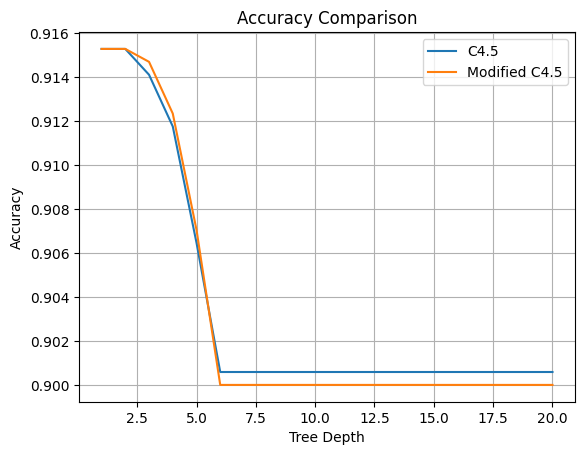

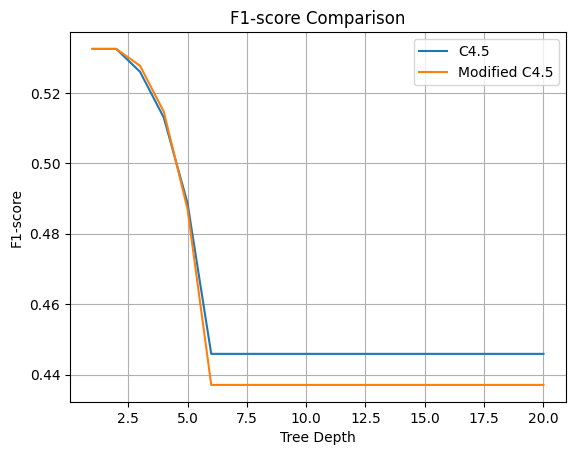

In [ ]:
import matplotlib.pyplot as plt

# ==============================
# DATA
# ==============================

depth = list(range(1, 21))

# C4.5 KLASIK
acc_c45 = [
0.915294,0.915294,0.914118,0.911765,0.906471,0.900588,0.900588,0.900588,0.900588,0.900588,
0.900588,0.900588,0.900588,0.900588,0.900588,0.900588,0.900588,0.900588,0.900588,0.900588
]

f1_c45 = [
0.532468,0.532468,0.525974,0.512987,0.488746,0.445902,0.445902,0.445902,0.445902,0.445902,
0.445902,0.445902,0.445902,0.445902,0.445902,0.445902,0.445902,0.445902,0.445902,0.445902
]

# C4.5 MODIFIKASI
acc_mod = [
0.915294,0.915294,0.914706,0.912353,0.907059,0.900000,0.900000,0.900000,0.900000,0.900000,
0.900000,0.900000,0.900000,0.900000,0.900000,0.900000,0.900000,0.900000,0.900000,0.900000
]

f1_mod = [
0.532468,0.532468,0.527687,0.514658,0.487013,0.437086,0.437086,0.437086,0.437086,0.437086,
0.437086,0.437086,0.437086,0.437086,0.437086,0.437086,0.437086,0.437086,0.437086,0.437086
]

# ==============================
# GRAFIK ACCURACY
# ==============================
plt.figure()
plt.plot(depth, acc_c45, label='C4.5')
plt.plot(depth, acc_mod, label='Modified C4.5')

plt.xlabel('Tree Depth')
plt.ylabel('Accuracy')
plt.title('Accuracy Comparison')
plt.legend()
plt.grid()

plt.show()

# ==============================
# GRAFIK F1-SCORE
# ==============================
plt.figure()
plt.plot(depth, f1_c45, label='C4.5')
plt.plot(depth, f1_mod, label='Modified C4.5')

plt.xlabel('Tree Depth')
plt.ylabel('F1-score')
plt.title('F1-score Comparison')
plt.legend()
plt.grid()

plt.show()

In [ ]:
df.head()

,Menu_Category,Order_Price,Delivery_Distance_KM,Waiting_Time_Minutes,Customer_Rating,Promo_Status,Complaint_Level
0,coffee,Low,Near,Slow,4.0,False,Low
1,noodle,Low,Far,Slow,5.0,False,Low
2,martabak,Medium,Far,Slow,5.0,True,Low
3,coffee,Low,Medium,Normal,5.0,False,Low
4,chicken,High,Near,Slow,4.0,True,Low


In [ ]:
import pandas as pd
import numpy as np
dt=pd.read_csv('food_delivery_.csv')
dt.head()

,Menu_Category,Order_Price,Delivery_Distance_KM,Waiting_Time_Minutes,Customer_Rating,Promo_Status,Complaint_Level,Order_Status
0,coffee,9000,0.500000,27,4.0,False,Low,Completed
1,noodle,21000,3.742238,37,5.0,False,Low,Completed
2,martabak,33500,12.677149,49,5.0,True,Low,Completed
3,coffee,13500,2.338085,20,5.0,False,Low,Completed
4,chicken,47500,0.949764,27,4.0,True,Low,Completed


In [ ]:
bins=[0.5,5,10,15,20.0]
names=['0.5-<=5','5-<=10','10-<=15','15-<=20','>20']
d = dict(enumerate(names, 1))
dt['Delivery_Distance_KM_Range']=np.vectorize(d.get)(np.digitize(dt['Delivery_Distance_KM'],bins))
dt['Delivery_Distance_KM_Range'].value_counts()
dt.head()

,Menu_Category,Order_Price,Delivery_Distance_KM,Waiting_Time_Minutes,Customer_Rating,Promo_Status,Complaint_Level,Order_Status,Delivery_Distance_KM_Range
0,coffee,9000,0.500000,27,4.0,False,Low,Completed,0.5-<=5
1,noodle,21000,3.742238,37,5.0,False,Low,Completed,0.5-<=5
2,martabak,33500,12.677149,49,5.0,True,Low,Completed,10-<=15
3,coffee,13500,2.338085,20,5.0,False,Low,Completed,0.5-<=5
4,chicken,47500,0.949764,27,4.0,True,Low,Completed,0.5-<=5


In [ ]:
bins=[5,20,35,50,65,80,95,105]
names=['5-<=20','>20-<=35','35-<=50','50-<=65','65-<=80','80-<=95','>95-<=105','>105']
d = dict(enumerate(names, 1))
dt['Waiting_Time_Minutes_Range']=np.vectorize(d.get)(np.digitize(dt['Waiting_Time_Minutes'],bins))
dt['Waiting_Time_Minutes_Range'].value_counts()
dt.head()

,Menu_Category,Order_Price,Delivery_Distance_KM,Waiting_Time_Minutes,Customer_Rating,Promo_Status,Complaint_Level,Order_Status,Delivery_Distance_KM_Range,Order_Price_Range,Waiting_Time_Minutes_Range
0,coffee,9000,0.500000,27,4.0,False,Low,Completed,0.5-<=5,0-<=500000,>20-<=35
1,noodle,21000,3.742238,37,5.0,False,Low,Completed,0.5-<=5,0-<=500000,35-<=50
2,martabak,33500,12.677149,49,5.0,True,Low,Completed,10-<=15,0-<=500000,35-<=50
3,coffee,13500,2.338085,20,5.0,False,Low,Completed,0.5-<=5,0-<=500000,>20-<=35
4,chicken,47500,0.949764,27,4.0,True,Low,Completed,0.5-<=5,0-<=500000,>20-<=35


In [ ]:
dt['Waiting_Time_Minutes_Range'].value_counts()

,count
Waiting_Time_Minutes_Range,
5-<=20,3910
>20-<=35,3154
35-<=50,1083
50-<=65,262
65-<=80,69
80-<=95,16
>95-<=105,4
>105,2


In [ ]:
bins=[0,500000,1500000,3000000,4000000,5000000,6000000,7000000,8000000]
names=['0-<=500000','>500000-<=1500000','>1500000-<=3000000','>3000000-<=4000000','>4000000-<=5000000',
       '>5000000-<=6000000','>6000000-<=7000000','>7000000-<8000000','>8000000']
d = dict(enumerate(names, 1))
dt['Order_Price_Range']=np.vectorize(d.get)(np.digitize(dt['Order_Price'],bins))
dt['Order_Price_Range'].value_counts()
dt.head()

,Menu_Category,Order_Price,Delivery_Distance_KM,Waiting_Time_Minutes,Customer_Rating,Promo_Status,Complaint_Level,Order_Status,Delivery_Distance_KM_Range,Order_Price_Range
0,coffee,9000,0.500000,27,4.0,False,Low,Completed,0.5-<=5,0-<=500000
1,noodle,21000,3.742238,37,5.0,False,Low,Completed,0.5-<=5,0-<=500000
2,martabak,33500,12.677149,49,5.0,True,Low,Completed,10-<=15,0-<=500000
3,coffee,13500,2.338085,20,5.0,False,Low,Completed,0.5-<=5,0-<=500000
4,chicken,47500,0.949764,27,4.0,True,Low,Completed,0.5-<=5,0-<=500000


In [ ]:
dt.head()

,Menu_Category,Order_Price,Delivery_Distance_KM,Waiting_Time_Minutes,Customer_Rating,Promo_Status,Complaint_Level,Order_Status,Delivery_Distance_KM_Range,Order_Price_Range,Waiting_Time_Minutes_Range
0,coffee,9000,0.500000,27,4.0,False,Low,Completed,0.5-<=5,0-<=500000,>20-<=35
1,noodle,21000,3.742238,37,5.0,False,Low,Completed,0.5-<=5,0-<=500000,35-<=50
2,martabak,33500,12.677149,49,5.0,True,Low,Completed,10-<=15,0-<=500000,35-<=50
3,coffee,13500,2.338085,20,5.0,False,Low,Completed,0.5-<=5,0-<=500000,>20-<=35
4,chicken,47500,0.949764,27,4.0,True,Low,Completed,0.5-<=5,0-<=500000,>20-<=35


In [ ]:
dt.drop(['Order_Price','Delivery_Distance_KM','Waiting_Time_Minutes'],axis=1,inplace=True)
dt.head()

,Menu_Category,Customer_Rating,Promo_Status,Complaint_Level,Order_Status,Delivery_Distance_KM_Range,Order_Price_Range,Waiting_Time_Minutes_Range
0,coffee,4.0,False,Low,Completed,0.5-<=5,0-<=500000,>20-<=35
1,noodle,5.0,False,Low,Completed,0.5-<=5,0-<=500000,35-<=50
2,martabak,5.0,True,Low,Completed,10-<=15,0-<=500000,35-<=50
3,coffee,5.0,False,Low,Completed,0.5-<=5,0-<=500000,>20-<=35
4,chicken,4.0,True,Low,Completed,0.5-<=5,0-<=500000,>20-<=35


In [ ]:
# Save new dataset
output_path = 'food_delivery_categorical.csv'
dt.to_csv(output_path, index=False)

In [ ]:
df=pd.read_csv('food_delivery_categorical.csv')
df.head()

,Menu_Category,Customer_Rating,Promo_Status,Complaint_Level,Order_Status,Delivery_Distance_KM_Range,Order_Price_Range,Waiting_Time_Minutes_Range
0,coffee,4.0,False,Low,Completed,0.5-<=5,0-<=500000,>20-<=35
1,noodle,5.0,False,Low,Completed,0.5-<=5,0-<=500000,35-<=50
2,martabak,5.0,True,Low,Completed,10-<=15,0-<=500000,35-<=50
3,coffee,5.0,False,Low,Completed,0.5-<=5,0-<=500000,>20-<=35
4,chicken,4.0,True,Low,Completed,0.5-<=5,0-<=500000,>20-<=35


**C4.5 Modifikasi**

In [ ]:
# ==============================
# IMPORT LIBRARY
# ==============================
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# ==============================
# LOAD DATA
# ==============================
df = pd.read_csv("food_delivery_categorical.csv")

# ==============================
# PILIH FITUR
# ==============================
selected_columns = [
    'Menu_Category',
    'Order_Price_Range',
    'Delivery_Distance_KM_Range',
    'Waiting_Time_Minutes_Range',
    'Customer_Rating',   # tetap numerik (boleh)
    'Promo_Status',
    'Complaint_Level'
]

df = df[selected_columns]

# ==============================
# CLEAN DATA
# ==============================
df = df.replace(['', 'None', 'nan', 'NaN'], np.nan)
df = df.dropna()

# ==============================
# KONVERSI BOOLEAN (OPSIONAL)
# ==============================
df['Promo_Status'] = df['Promo_Status'].astype(str)

# ==============================
# SPLIT DATA
# ==============================
target = 'Complaint_Level'

X = df.drop(columns=[target])
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

train_data = pd.concat([X_train, y_train], axis=1)

# ==============================
# ENTROPY
# ==============================
def entropy(S):
    values, counts = np.unique(S, return_counts=True)
    probs = counts / counts.sum()
    return -np.sum(probs * np.log2(probs + 1e-9))

# ==============================
# INFORMATION GAIN
# ==============================
def information_gain(data, feature, target):
    total_entropy = entropy(data[target])
    total = len(data)

    weighted_entropy = 0
    for v in data[feature].unique():
        subset = data[data[feature] == v]
        weighted_entropy += (len(subset)/total) * entropy(subset[target])

    return total_entropy - weighted_entropy

# ==============================
# SPLIT INFO
# ==============================
def split_info(data, feature):
    total = len(data)
    split = 0

    for v in data[feature].unique():
        subset = data[data[feature] == v]
        p = len(subset) / total
        split += -p * np.log2(p + 1e-9)

    return split

# ==============================
# GAIN RATIO (MODIFIED)
# ==============================
def gain_ratio(data, feature, target):
    gain = information_gain(data, feature, target)
    split = split_info(data, feature)
    return (gain**2) / split if split != 0 else 0

# ==============================
# SELECT BEST FEATURE
# ==============================
def select_best_feature(data, features, target):
    scores = [gain_ratio(data, f, target) for f in features]
    return features[np.argmax(scores)]

# ==============================
# BUILD TREE
# ==============================
def build_tree(data, features, target, depth=0, max_depth=6):

    if len(np.unique(data[target])) == 1:
        return data[target].iloc[0]

    if len(features) == 0 or depth == max_depth:
        return data[target].mode()[0]

    best_feature = select_best_feature(data, features, target)
    tree = {best_feature: {}}

    for value in data[best_feature].unique():
        subset = data[data[best_feature] == value]

        if len(subset) == 0:
            tree[best_feature][value] = data[target].mode()[0]
        else:
            remaining = [f for f in features if f != best_feature]
            tree[best_feature][value] = build_tree(
                subset, remaining, target, depth+1, max_depth
            )

    return tree

# ==============================
# PREDICT
# ==============================
def predict(tree, sample):
    if not isinstance(tree, dict):
        return tree

    root = list(tree.keys())[0]

    if sample[root] in tree[root]:
        return predict(tree[root][sample[root]], sample)
    else:
        return y_train.mode()[0]

# ==============================
# ITERASI DEPTH 1–20
# ==============================
results = []
features = list(X_train.columns)

for d in range(1, 21):

    tree_model = build_tree(train_data, features, target, max_depth=d)

    y_pred = [predict(tree_model, row) for row in X_test.to_dict('records')]

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, pos_label='High', zero_division=0)
    rec = recall_score(y_test, y_pred, pos_label='High', zero_division=0)
    f1 = f1_score(y_test, y_pred, pos_label='High', zero_division=0)

    results.append([d, acc, prec, rec, f1])

# ==============================
# HASIL
# ==============================
results_df = pd.DataFrame(results, columns=[
    'Depth','Accuracy','Precision','Recall','F1-score'
])

print("=== HASIL C4.5 MODIFIKASI (DATA SUDAH DISKRIT) ===")
print(results_df)

=== HASIL C4.5 MODIFIKASI (DATA SUDAH DISKRIT) ===
    Depth  Accuracy  Precision    Recall  F1-score
0       1  0.918824   0.813665  0.425325  0.558635
1       2  0.918431   0.808642  0.425325  0.557447
2       3  0.916078   0.779762  0.425325  0.550420
3       4  0.914902   0.775758  0.415584  0.541226
4       5  0.902745   0.700000  0.340909  0.458515
5       6  0.900000   0.660606  0.353896  0.460888
6       7  0.900000   0.660606  0.353896  0.460888
7       8  0.900000   0.660606  0.353896  0.460888
8       9  0.900000   0.660606  0.353896  0.460888
9      10  0.900000   0.660606  0.353896  0.460888
10     11  0.900000   0.660606  0.353896  0.460888
11     12  0.900000   0.660606  0.353896  0.460888
12     13  0.900000   0.660606  0.353896  0.460888
13     14  0.900000   0.660606  0.353896  0.460888
14     15  0.900000   0.660606  0.353896  0.460888
15     16  0.900000   0.660606  0.353896  0.460888
16     17  0.900000   0.660606  0.353896  0.460888
17     18  0.900000   0.660606 

**C4.5 Klasik**

In [ ]:
# ==============================
# IMPORT LIBRARY
# ==============================
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# ==============================
# LOAD DATA
# ==============================
df = pd.read_csv("food_delivery_categorical.csv")

# ==============================
# PILIH FITUR
# ==============================
selected_columns = [
    'Menu_Category',
    'Order_Price_Range',
    'Delivery_Distance_KM_Range',
    'Waiting_Time_Minutes_Range',
    'Customer_Rating',   # tetap numerik (boleh)
    'Promo_Status',
    'Complaint_Level'
]

df = df[selected_columns]

# ==============================
# CLEAN DATA
# ==============================
df = df.replace(['', 'None', 'nan', 'NaN'], np.nan)
df = df.dropna()

# ==============================
# KONVERSI BOOLEAN (OPSIONAL)
# ==============================
df['Promo_Status'] = df['Promo_Status'].astype(str)

# ==============================
# SPLIT DATA
# ==============================
target = 'Complaint_Level'

X = df.drop(columns=[target])
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

train_data = pd.concat([X_train, y_train], axis=1)

# ==============================
# ENTROPY
# ==============================
def entropy(S):
    values, counts = np.unique(S, return_counts=True)
    probs = counts / counts.sum()
    return -np.sum(probs * np.log2(probs + 1e-9))

# ==============================
# INFORMATION GAIN
# ==============================
def information_gain(data, feature, target):
    total_entropy = entropy(data[target])
    total = len(data)

    weighted_entropy = 0
    for v in data[feature].unique():
        subset = data[data[feature] == v]
        weighted_entropy += (len(subset)/total) * entropy(subset[target])

    return total_entropy - weighted_entropy

# ==============================
# SPLIT INFO
# ==============================
def split_info(data, feature):
    total = len(data)
    split = 0

    for v in data[feature].unique():
        subset = data[data[feature] == v]
        p = len(subset) / total
        split += -p * np.log2(p + 1e-9)

    return split

# ==============================
# GAIN RATIO (MODIFIED)
# ==============================
def gain_ratio(data, feature, target):
    gain = information_gain(data, feature, target)
    split = split_info(data, feature)
    return gain / split if split != 0 else 0

# ==============================
# SELECT BEST FEATURE
# ==============================
def select_best_feature(data, features, target):
    scores = [gain_ratio(data, f, target) for f in features]
    return features[np.argmax(scores)]

# ==============================
# BUILD TREE
# ==============================
def build_tree(data, features, target, depth=0, max_depth=6):

    if len(np.unique(data[target])) == 1:
        return data[target].iloc[0]

    if len(features) == 0 or depth == max_depth:
        return data[target].mode()[0]

    best_feature = select_best_feature(data, features, target)
    tree = {best_feature: {}}

    for value in data[best_feature].unique():
        subset = data[data[best_feature] == value]

        if len(subset) == 0:
            tree[best_feature][value] = data[target].mode()[0]
        else:
            remaining = [f for f in features if f != best_feature]
            tree[best_feature][value] = build_tree(
                subset, remaining, target, depth+1, max_depth
            )

    return tree

# ==============================
# PREDICT
# ==============================
def predict(tree, sample):
    if not isinstance(tree, dict):
        return tree

    root = list(tree.keys())[0]

    if sample[root] in tree[root]:
        return predict(tree[root][sample[root]], sample)
    else:
        return y_train.mode()[0]

# ==============================
# ITERASI DEPTH 1–20
# ==============================
results = []
features = list(X_train.columns)

for d in range(1, 21):

    tree_model = build_tree(train_data, features, target, max_depth=d)

    y_pred = [predict(tree_model, row) for row in X_test.to_dict('records')]

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, pos_label='High', zero_division=0)
    rec = recall_score(y_test, y_pred, pos_label='High', zero_division=0)
    f1 = f1_score(y_test, y_pred, pos_label='High', zero_division=0)

    results.append([d, acc, prec, rec, f1])

# ==============================
# HASIL
# ==============================
results_df = pd.DataFrame(results, columns=[
    'Depth','Accuracy','Precision','Recall','F1-score'
])

print("=== HASIL C4.5 Klasik (DATA SUDAH DISKRIT) ===")
print(results_df)

=== HASIL C4.5 Klasik (DATA SUDAH DISKRIT) ===
    Depth  Accuracy  Precision    Recall  F1-score
0       1  0.918824   0.813665  0.425325  0.558635
1       2  0.918431   0.808642  0.425325  0.557447
2       3  0.915294   0.770588  0.425325  0.548117
3       4  0.915686   0.785276  0.415584  0.543524
4       5  0.907059   0.726115  0.370130  0.490323
5       6  0.900784   0.666667  0.357143  0.465116
6       7  0.900784   0.666667  0.357143  0.465116
7       8  0.900784   0.666667  0.357143  0.465116
8       9  0.900784   0.666667  0.357143  0.465116
9      10  0.900784   0.666667  0.357143  0.465116
10     11  0.900784   0.666667  0.357143  0.465116
11     12  0.900784   0.666667  0.357143  0.465116
12     13  0.900784   0.666667  0.357143  0.465116
13     14  0.900784   0.666667  0.357143  0.465116
14     15  0.900784   0.666667  0.357143  0.465116
15     16  0.900784   0.666667  0.357143  0.465116
16     17  0.900784   0.666667  0.357143  0.465116
17     18  0.900784   0.666667  0.3

**Grafik**

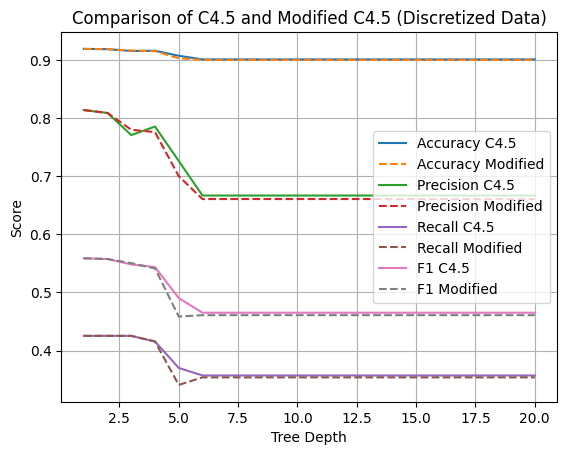

In [ ]:
import matplotlib.pyplot as plt

depth = list(range(1, 21))

# ==============================
# C4.5 KLASIK
# ==============================
acc_c45 = [0.918824,0.918431,0.915294,0.915686,0.907059,0.900784,0.900784,0.900784,0.900784,0.900784,
           0.900784,0.900784,0.900784,0.900784,0.900784,0.900784,0.900784,0.900784,0.900784,0.900784]

prec_c45 = [0.813665,0.808642,0.770588,0.785276,0.726115,0.666667,0.666667,0.666667,0.666667,0.666667,
            0.666667,0.666667,0.666667,0.666667,0.666667,0.666667,0.666667,0.666667,0.666667,0.666667]

rec_c45 = [0.425325,0.425325,0.425325,0.415584,0.370130,0.357143,0.357143,0.357143,0.357143,0.357143,
           0.357143,0.357143,0.357143,0.357143,0.357143,0.357143,0.357143,0.357143,0.357143,0.357143]

f1_c45 = [0.558635,0.557447,0.548117,0.543524,0.490323,0.465116,0.465116,0.465116,0.465116,0.465116,
          0.465116,0.465116,0.465116,0.465116,0.465116,0.465116,0.465116,0.465116,0.465116,0.465116]

# ==============================
# MODIFIED C4.5
# ==============================
acc_mod = [0.918824,0.918431,0.916078,0.914902,0.902745,0.900000,0.900000,0.900000,0.900000,0.900000,
           0.900000,0.900000,0.900000,0.900000,0.900000,0.900000,0.900000,0.900000,0.900000,0.900000]

prec_mod = [0.813665,0.808642,0.779762,0.775758,0.700000,0.660606,0.660606,0.660606,0.660606,0.660606,
            0.660606,0.660606,0.660606,0.660606,0.660606,0.660606,0.660606,0.660606,0.660606,0.660606]

rec_mod = [0.425325,0.425325,0.425325,0.415584,0.340909,0.353896,0.353896,0.353896,0.353896,0.353896,
           0.353896,0.353896,0.353896,0.353896,0.353896,0.353896,0.353896,0.353896,0.353896,0.353896]

f1_mod = [0.558635,0.557447,0.550420,0.541226,0.458515,0.460888,0.460888,0.460888,0.460888,0.460888,
          0.460888,0.460888,0.460888,0.460888,0.460888,0.460888,0.460888,0.460888,0.460888,0.460888]

# ==============================
# PLOT SEMUA DALAM 1 FIGURE
# ==============================
plt.figure()

# Accuracy
plt.plot(depth, acc_c45, linestyle='-', label='Accuracy C4.5')
plt.plot(depth, acc_mod, linestyle='--', label='Accuracy Modified')

# Precision
plt.plot(depth, prec_c45, linestyle='-', label='Precision C4.5')
plt.plot(depth, prec_mod, linestyle='--', label='Precision Modified')

# Recall
plt.plot(depth, rec_c45, linestyle='-', label='Recall C4.5')
plt.plot(depth, rec_mod, linestyle='--', label='Recall Modified')

# F1-score
plt.plot(depth, f1_c45, linestyle='-', label='F1 C4.5')
plt.plot(depth, f1_mod, linestyle='--', label='F1 Modified')

plt.xlabel('Tree Depth')
plt.ylabel('Score')
plt.title('Comparison of C4.5 and Modified C4.5 (Discretized Data)')
plt.legend()
plt.grid()

plt.show()

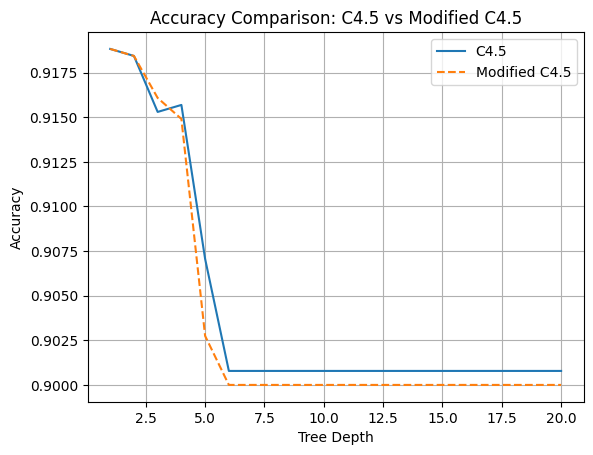

In [ ]:
import matplotlib.pyplot as plt

# Depth
depth = list(range(1, 21))

# Accuracy C4.5
acc_c45 = [
    0.918824, 0.918431, 0.915294, 0.915686, 0.907059,
    0.900784, 0.900784, 0.900784, 0.900784, 0.900784,
    0.900784, 0.900784, 0.900784, 0.900784, 0.900784,
    0.900784, 0.900784, 0.900784, 0.900784, 0.900784
]

# Accuracy Modified C4.5
acc_mod = [
    0.918824, 0.918431, 0.916078, 0.914902, 0.902745,
    0.900000, 0.900000, 0.900000, 0.900000, 0.900000,
    0.900000, 0.900000, 0.900000, 0.900000, 0.900000,
    0.900000, 0.900000, 0.900000, 0.900000, 0.900000
]

# Plot
plt.figure()

plt.plot(depth, acc_c45, label='C4.5')
plt.plot(depth, acc_mod, linestyle='--', label='Modified C4.5')

plt.xlabel('Tree Depth')
plt.ylabel('Accuracy')
plt.title('Accuracy Comparison: C4.5 vs Modified C4.5')
plt.legend()
plt.grid()

plt.show()

In [6]:
# ==============================
# IMPORT LIBRARY
# ==============================
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

# ==============================
# LOAD DATA
# ==============================
df = pd.read_csv("food_delivery_categorical.csv")

# ==============================
# PILIH FITUR
# ==============================
selected_columns = [
    'Menu_Category',
    'Order_Price_Range',
    'Delivery_Distance_KM_Range',
    'Waiting_Time_Minutes_Range',
    'Customer_Rating',
    'Promo_Status',
    'Complaint_Level'
]

df = df[selected_columns]

# ==============================
# CLEAN DATA
# ==============================
df = df.replace(['', 'None', 'nan', 'NaN'], np.nan)
df = df.dropna()

# ==============================
# KONVERSI BOOLEAN
# ==============================
df['Promo_Status'] = df['Promo_Status'].astype(str)

# ==============================
# SPLIT DATA
# ==============================
target = 'Complaint_Level'

X = df.drop(columns=[target])
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

train_data = pd.concat([X_train, y_train], axis=1)

# ==============================
# ENTROPY
# ==============================
def entropy(S):
    values, counts = np.unique(S, return_counts=True)
    probs = counts / counts.sum()
    return -np.sum(probs * np.log2(probs + 1e-9))

# ==============================
# INFORMATION GAIN
# ==============================
def information_gain(data, feature, target):
    total_entropy = entropy(data[target])
    total = len(data)

    weighted_entropy = 0
    for v in data[feature].unique():
        subset = data[data[feature] == v]
        weighted_entropy += (len(subset)/total) * entropy(subset[target])

    return total_entropy - weighted_entropy

# ==============================
# SPLIT INFO
# ==============================
def split_info(data, feature):
    total = len(data)
    split = 0

    for v in data[feature].unique():
        subset = data[data[feature] == v]
        p = len(subset) / total
        split += -p * np.log2(p + 1e-9)

    return split

# ==============================
# GAIN RATIO MODIFIKASI
# ==============================
def gain_ratio(data, feature, target):
    gain = information_gain(data, feature, target)
    split = split_info(data, feature)
    return (gain**2) / split if split != 0 else 0

# ==============================
# SELECT BEST FEATURE
# ==============================
def select_best_feature(data, features, target):
    scores = [gain_ratio(data, f, target) for f in features]
    return features[np.argmax(scores)]

# ==============================
# BUILD TREE (max_depth = 5)
# ==============================
def build_tree(data, features, target, depth=0, max_depth=5):

    if len(np.unique(data[target])) == 1:
        return data[target].iloc[0]

    if len(features) == 0 or depth == max_depth:
        return data[target].mode()[0]

    best_feature = select_best_feature(data, features, target)
    tree = {best_feature: {}}

    for value in data[best_feature].unique():
        subset = data[data[best_feature] == value]

        if len(subset) == 0:
            tree[best_feature][value] = data[target].mode()[0]
        else:
            remaining = [f for f in features if f != best_feature]
            tree[best_feature][value] = build_tree(
                subset, remaining, target, depth+1, max_depth
            )

    return tree

# ==============================
# PREDICT
# ==============================
def predict(tree, sample):
    if not isinstance(tree, dict):
        return tree

    root = list(tree.keys())[0]

    if sample[root] in tree[root]:
        return predict(tree[root][sample[root]], sample)
    else:
        return y_train.mode()[0]

# ==============================
# TRAIN MODEL (DEPTH = 3)
# ==============================
features = list(X_train.columns)

tree_model = build_tree(train_data, features, target, max_depth=3)

# ==============================
# PREDIKSI
# ==============================
y_pred = [predict(tree_model, row) for row in X_test.to_dict('records')]

# ==============================
# EVALUASI
# ==============================
print("=== C4.5 MODIFIED (Depth = 3) ===")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

=== C4.5 MODIFIED (Depth = 3) ===
Accuracy: 0.9160784313725491

Classification Report:
              precision    recall  f1-score   support

        High       0.78      0.43      0.55       308
         Low       0.93      0.98      0.95      2242

    accuracy                           0.92      2550
   macro avg       0.85      0.70      0.75      2550
weighted avg       0.91      0.92      0.91      2550



In [5]:
# ==============================
# IMPORT LIBRARY
# ==============================
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

# ==============================
# LOAD DATA
# ==============================
df = pd.read_csv("food_delivery_categorical.csv")

# ==============================
# PILIH FITUR
# ==============================
selected_columns = [
    'Menu_Category',
    'Order_Price_Range',
    'Delivery_Distance_KM_Range',
    'Waiting_Time_Minutes_Range',
    'Customer_Rating',
    'Promo_Status',
    'Complaint_Level'
]

df = df[selected_columns]

# ==============================
# CLEAN DATA
# ==============================
df = df.replace(['', 'None', 'nan', 'NaN'], np.nan)
df = df.dropna()

# ==============================
# KONVERSI BOOLEAN
# ==============================
df['Promo_Status'] = df['Promo_Status'].astype(str)

# ==============================
# SPLIT DATA
# ==============================
target = 'Complaint_Level'

X = df.drop(columns=[target])
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

train_data = pd.concat([X_train, y_train], axis=1)

# ==============================
# ENTROPY
# ==============================
def entropy(S):
    values, counts = np.unique(S, return_counts=True)
    probs = counts / counts.sum()
    return -np.sum(probs * np.log2(probs + 1e-9))

# ==============================
# INFORMATION GAIN
# ==============================
def information_gain(data, feature, target):
    total_entropy = entropy(data[target])
    total = len(data)

    weighted_entropy = 0
    for v in data[feature].unique():
        subset = data[data[feature] == v]
        weighted_entropy += (len(subset)/total) * entropy(subset[target])

    return total_entropy - weighted_entropy

# ==============================
# SPLIT INFO
# ==============================
def split_info(data, feature):
    total = len(data)
    split = 0

    for v in data[feature].unique():
        subset = data[data[feature] == v]
        p = len(subset) / total
        split += -p * np.log2(p + 1e-9)

    return split

# ==============================
# GAIN RATIO MODIFIKASI
# ==============================
def gain_ratio(data, feature, target):
    gain = information_gain(data, feature, target)
    split = split_info(data, feature)
    return gain/ split if split != 0 else 0

# ==============================
# SELECT BEST FEATURE
# ==============================
def select_best_feature(data, features, target):
    scores = [gain_ratio(data, f, target) for f in features]
    return features[np.argmax(scores)]

# ==============================
# BUILD TREE (max_depth = 5)
# ==============================
def build_tree(data, features, target, depth=0, max_depth=5):

    if len(np.unique(data[target])) == 1:
        return data[target].iloc[0]

    if len(features) == 0 or depth == max_depth:
        return data[target].mode()[0]

    best_feature = select_best_feature(data, features, target)
    tree = {best_feature: {}}

    for value in data[best_feature].unique():
        subset = data[data[best_feature] == value]

        if len(subset) == 0:
            tree[best_feature][value] = data[target].mode()[0]
        else:
            remaining = [f for f in features if f != best_feature]
            tree[best_feature][value] = build_tree(
                subset, remaining, target, depth+1, max_depth
            )

    return tree

# ==============================
# PREDICT
# ==============================
def predict(tree, sample):
    if not isinstance(tree, dict):
        return tree

    root = list(tree.keys())[0]

    if sample[root] in tree[root]:
        return predict(tree[root][sample[root]], sample)
    else:
        return y_train.mode()[0]

# ==============================
# TRAIN MODEL (DEPTH = 3)
# ==============================
features = list(X_train.columns)

tree_model = build_tree(train_data, features, target, max_depth=3)

# ==============================
# PREDIKSI
# ==============================
y_pred = [predict(tree_model, row) for row in X_test.to_dict('records')]

# ==============================
# EVALUASI
# ==============================
print("=== C4.5 Klasik (Depth = 3) ===")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

=== C4.5 Klasik (Depth = 3) ===
Accuracy: 0.9152941176470588

Classification Report:
              precision    recall  f1-score   support

        High       0.77      0.43      0.55       308
         Low       0.93      0.98      0.95      2242

    accuracy                           0.92      2550
   macro avg       0.85      0.70      0.75      2550
weighted avg       0.91      0.92      0.90      2550



**Bias**

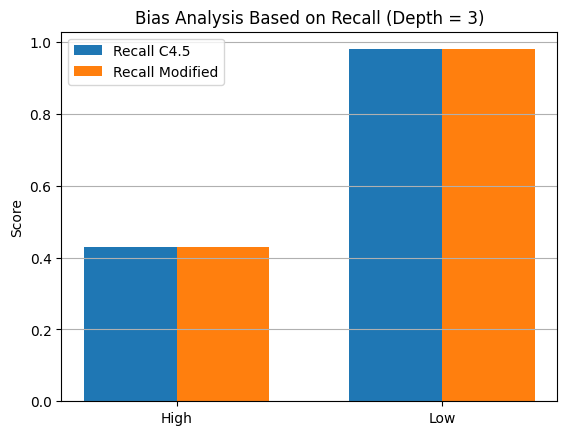

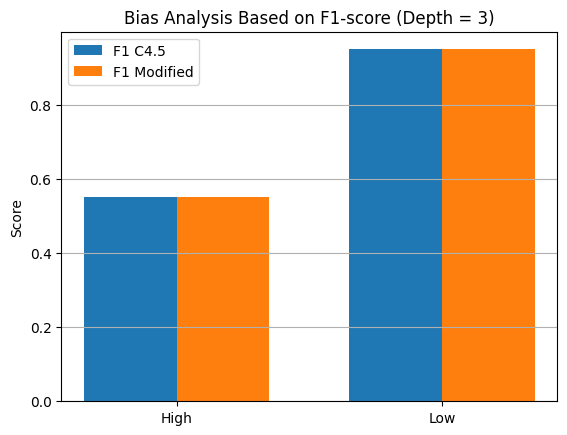

In [12]:
import matplotlib.pyplot as plt
import numpy as np

# ==============================
# DATA PER CLASS (Depth = 3)
# ==============================
classes = ['High', 'Low']

# Recall
recall_c45 = [0.43, 0.98]
recall_mod = [0.43, 0.98]

# F1-score
f1_c45 = [0.55, 0.95]
f1_mod = [0.55, 0.95]

x = np.arange(len(classes))
width = 0.35

# ==============================
# PLOT RECALL (BIAS)
# ==============================
plt.figure()

plt.bar(x - width/2, recall_c45, width, label='Recall C4.5')
plt.bar(x + width/2, recall_mod, width, label='Recall Modified')

plt.xticks(x, classes)
plt.ylabel('Score')
plt.title('Bias Analysis Based on Recall (Depth = 3)')
plt.legend()
plt.grid(axis='y')

plt.show()

# ==============================
# PLOT F1-SCORE (BIAS)
# ==============================
plt.figure()

plt.bar(x - width/2, f1_c45, width, label='F1 C4.5')
plt.bar(x + width/2, f1_mod, width, label='F1 Modified')

plt.xticks(x, classes)
plt.ylabel('Score')
plt.title('Bias Analysis Based on F1-score (Depth = 3)')
plt.legend()
plt.grid(axis='y')

plt.show()

**Menggunakan Pembagian Data K-Fold 5 C4.5 Klasik**

In [8]:
# ==============================
# IMPORT LIBRARY
# ==============================
import pandas as pd
import numpy as np
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# ==============================
# LOAD DATA
# ==============================
df = pd.read_csv("food_delivery_categorical.csv")

# ==============================
# PILIH FITUR
# ==============================
selected_columns = [
    'Menu_Category',
    'Order_Price_Range',
    'Delivery_Distance_KM_Range',
    'Waiting_Time_Minutes_Range',
    'Customer_Rating',
    'Promo_Status',
    'Complaint_Level'
]

df = df[selected_columns]

# ==============================
# CLEAN DATA
# ==============================
df = df.replace(['', 'None', 'nan', 'NaN'], np.nan)
df = df.dropna()

df['Promo_Status'] = df['Promo_Status'].astype(str)

# ==============================
# DATA
# ==============================
target = 'Complaint_Level'
X = df.drop(columns=[target])
y = df[target]

# ==============================
# ENTROPY
# ==============================
def entropy(S):
    values, counts = np.unique(S, return_counts=True)
    probs = counts / counts.sum()
    return -np.sum(probs * np.log2(probs + 1e-9))

# ==============================
# INFORMATION GAIN
# ==============================
def information_gain(data, feature, target):
    total_entropy = entropy(data[target])
    total = len(data)

    weighted_entropy = 0
    for v in data[feature].unique():
        subset = data[data[feature] == v]
        weighted_entropy += (len(subset)/total) * entropy(subset[target])

    return total_entropy - weighted_entropy

# ==============================
# SPLIT INFO
# ==============================
def split_info(data, feature):
    total = len(data)
    split = 0

    for v in data[feature].unique():
        subset = data[data[feature] == v]
        p = len(subset) / total
        split += -p * np.log2(p + 1e-9)

    return split

# ==============================
# GAIN RATIO
# ==============================
def gain_ratio(data, feature, target):
    gain = information_gain(data, feature, target)
    split = split_info(data, feature)
    return gain / split if split != 0 else 0

# ==============================
# SELECT BEST FEATURE
# ==============================
def select_best_feature(data, features, target):
    scores = [gain_ratio(data, f, target) for f in features]
    return features[np.argmax(scores)]

# ==============================
# BUILD TREE
# ==============================
def build_tree(data, features, target, depth=0, max_depth=6):

    if len(np.unique(data[target])) == 1:
        return data[target].iloc[0]

    if len(features) == 0 or depth == max_depth:
        return data[target].mode()[0]

    best_feature = select_best_feature(data, features, target)
    tree = {best_feature: {}}

    for value in data[best_feature].unique():
        subset = data[data[best_feature] == value]

        if len(subset) == 0:
            tree[best_feature][value] = data[target].mode()[0]
        else:
            remaining = [f for f in features if f != best_feature]
            tree[best_feature][value] = build_tree(
                subset, remaining, target, depth+1, max_depth
            )

    return tree

# ==============================
# PREDICT
# ==============================
def predict(tree, sample, default):
    if not isinstance(tree, dict):
        return tree

    root = list(tree.keys())[0]

    if sample[root] in tree[root]:
        return predict(tree[root][sample[root]], sample, default)
    else:
        return default

# ==============================
# K-FOLD CROSS VALIDATION
# ==============================
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

results = []
features = list(X.columns)

for d in range(1, 21):

    acc_list, prec_list, rec_list, f1_list = [], [], [], []

    for train_index, test_index in kf.split(X, y):

        X_train, X_test = X.iloc[train_index], X.iloc[test_index]
        y_train, y_test = y.iloc[train_index], y.iloc[test_index]

        train_data = pd.concat([X_train, y_train], axis=1)

        # build tree
        tree_model = build_tree(train_data, features, target, max_depth=d)

        default_class = y_train.mode()[0]

        # prediction
        y_pred = [
            predict(tree_model, row, default_class)
            for row in X_test.to_dict('records')
        ]

        # metrics
        acc_list.append(accuracy_score(y_test, y_pred))
        prec_list.append(precision_score(y_test, y_pred, pos_label='High', zero_division=0))
        rec_list.append(recall_score(y_test, y_pred, pos_label='High', zero_division=0))
        f1_list.append(f1_score(y_test, y_pred, pos_label='High', zero_division=0))

    # rata-rata 10 fold
    results.append([
        d,
        np.mean(acc_list),
        np.mean(prec_list),
        np.mean(rec_list),
        np.mean(f1_list)
    ])

# ==============================
# HASIL
# ==============================
results_df = pd.DataFrame(results, columns=[
    'Depth','Accuracy','Precision','Recall','F1-score'
])

print("=== HASIL C4.5 Klasik (5-Fold Cross Validation) ===")
print(results_df)

=== HASIL C4.5 Klasik (10-Fold Cross Validation) ===
    Depth  Accuracy  Precision    Recall  F1-score
0       1  0.913882   0.780747  0.398622  0.527416
1       2  0.912824   0.773056  0.393758  0.521315
2       3  0.911294   0.756722  0.391807  0.515826
3       4  0.910118   0.746462  0.386952  0.509292
4       5  0.907412   0.725449  0.376230  0.495122
5       6  0.902588   0.691702  0.348927  0.463130
6       7  0.902588   0.691702  0.348927  0.463130
7       8  0.902588   0.691702  0.348927  0.463130
8       9  0.902588   0.691702  0.348927  0.463130
9      10  0.902588   0.691702  0.348927  0.463130
10     11  0.902588   0.691702  0.348927  0.463130
11     12  0.902588   0.691702  0.348927  0.463130
12     13  0.902588   0.691702  0.348927  0.463130
13     14  0.902588   0.691702  0.348927  0.463130
14     15  0.902588   0.691702  0.348927  0.463130
15     16  0.902588   0.691702  0.348927  0.463130
16     17  0.902588   0.691702  0.348927  0.463130
17     18  0.902588   0.69170

**C4.5 Modifikasi K-Fold 5**

In [10]:
# ==============================
# IMPORT LIBRARY
# ==============================
import pandas as pd
import numpy as np
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# ==============================
# LOAD DATA
# ==============================
df = pd.read_csv("food_delivery_categorical.csv")

# ==============================
# PILIH FITUR
# ==============================
selected_columns = [
    'Menu_Category',
    'Order_Price_Range',
    'Delivery_Distance_KM_Range',
    'Waiting_Time_Minutes_Range',
    'Customer_Rating',
    'Promo_Status',
    'Complaint_Level'
]

df = df[selected_columns]

# ==============================
# CLEAN DATA
# ==============================
df = df.replace(['', 'None', 'nan', 'NaN'], np.nan)
df = df.dropna()

df['Promo_Status'] = df['Promo_Status'].astype(str)

# ==============================
# DATA
# ==============================
target = 'Complaint_Level'
X = df.drop(columns=[target])
y = df[target]

# ==============================
# ENTROPY
# ==============================
def entropy(S):
    values, counts = np.unique(S, return_counts=True)
    probs = counts / counts.sum()
    return -np.sum(probs * np.log2(probs + 1e-9))

# ==============================
# INFORMATION GAIN
# ==============================
def information_gain(data, feature, target):
    total_entropy = entropy(data[target])
    total = len(data)

    weighted_entropy = 0
    for v in data[feature].unique():
        subset = data[data[feature] == v]
        weighted_entropy += (len(subset)/total) * entropy(subset[target])

    return total_entropy - weighted_entropy

# ==============================
# SPLIT INFO
# ==============================
def split_info(data, feature):
    total = len(data)
    split = 0

    for v in data[feature].unique():
        subset = data[data[feature] == v]
        p = len(subset) / total
        split += -p * np.log2(p + 1e-9)

    return split

# ==============================
# GAIN RATIO
# ==============================
def gain_ratio(data, feature, target):
    gain = information_gain(data, feature, target)
    split = split_info(data, feature)
    return (gain)**2 / split if split != 0 else 0

# ==============================
# SELECT BEST FEATURE
# ==============================
def select_best_feature(data, features, target):
    scores = [gain_ratio(data, f, target) for f in features]
    return features[np.argmax(scores)]

# ==============================
# BUILD TREE
# ==============================
def build_tree(data, features, target, depth=0, max_depth=6):

    if len(np.unique(data[target])) == 1:
        return data[target].iloc[0]

    if len(features) == 0 or depth == max_depth:
        return data[target].mode()[0]

    best_feature = select_best_feature(data, features, target)
    tree = {best_feature: {}}

    for value in data[best_feature].unique():
        subset = data[data[best_feature] == value]

        if len(subset) == 0:
            tree[best_feature][value] = data[target].mode()[0]
        else:
            remaining = [f for f in features if f != best_feature]
            tree[best_feature][value] = build_tree(
                subset, remaining, target, depth+1, max_depth
            )

    return tree

# ==============================
# PREDICT
# ==============================
def predict(tree, sample, default):
    if not isinstance(tree, dict):
        return tree

    root = list(tree.keys())[0]

    if sample[root] in tree[root]:
        return predict(tree[root][sample[root]], sample, default)
    else:
        return default

# ==============================
# K-FOLD CROSS VALIDATION
# ==============================
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

results = []
features = list(X.columns)

for d in range(1, 21):

    acc_list, prec_list, rec_list, f1_list = [], [], [], []

    for train_index, test_index in kf.split(X, y):

        X_train, X_test = X.iloc[train_index], X.iloc[test_index]
        y_train, y_test = y.iloc[train_index], y.iloc[test_index]

        train_data = pd.concat([X_train, y_train], axis=1)

        # build tree
        tree_model = build_tree(train_data, features, target, max_depth=d)

        default_class = y_train.mode()[0]

        # prediction
        y_pred = [
            predict(tree_model, row, default_class)
            for row in X_test.to_dict('records')
        ]

        # metrics
        acc_list.append(accuracy_score(y_test, y_pred))
        prec_list.append(precision_score(y_test, y_pred, pos_label='High', zero_division=0))
        rec_list.append(recall_score(y_test, y_pred, pos_label='High', zero_division=0))
        f1_list.append(f1_score(y_test, y_pred, pos_label='High', zero_division=0))

    # rata-rata 10 fold
    results.append([
        d,
        np.mean(acc_list),
        np.mean(prec_list),
        np.mean(rec_list),
        np.mean(f1_list)
    ])

# ==============================
# HASIL
# ==============================
results_df = pd.DataFrame(results, columns=[
    'Depth','Accuracy','Precision','Recall','F1-score'
])

print("=== HASIL C4.5 Modifikasi (5-Fold Cross Validation) ===")
print(results_df)

=== HASIL C4.5 Modifikasi (5-Fold Cross Validation) ===
    Depth  Accuracy  Precision    Recall  F1-score
0       1  0.913882   0.780747  0.398622  0.527416
1       2  0.912471   0.769533  0.392782  0.519668
2       3  0.911294   0.756255  0.392782  0.516328
3       4  0.909882   0.745170  0.385001  0.507483
4       5  0.907059   0.721701  0.374279  0.492805
5       6  0.902588   0.691633  0.348927  0.463127
6       7  0.902588   0.691633  0.348927  0.463127
7       8  0.902588   0.691633  0.348927  0.463127
8       9  0.902588   0.691633  0.348927  0.463127
9      10  0.902588   0.691633  0.348927  0.463127
10     11  0.902588   0.691633  0.348927  0.463127
11     12  0.902588   0.691633  0.348927  0.463127
12     13  0.902588   0.691633  0.348927  0.463127
13     14  0.902588   0.691633  0.348927  0.463127
14     15  0.902588   0.691633  0.348927  0.463127
15     16  0.902588   0.691633  0.348927  0.463127
16     17  0.902588   0.691633  0.348927  0.463127
17     18  0.902588   0.69